### Imports and configuration

In [21]:

import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
TEST_SIZE = 0.20


CWD = Path.cwd()
PROJECT_ROOT = CWD.parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", DATA_DIR)


Project root: /home/patryk/Programming/MIO/social-media-engagement-prediction
Processed data directory: /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed


### Loading processed features and metadata

In [22]:

X_tfidf = sp.load_npz(DATA_DIR / "X_tfidf_features.npz")
X_count = sp.load_npz(DATA_DIR / "X_count_features.npz")

y = np.load(DATA_DIR / "y_labels.npy")
label_classes = np.load(DATA_DIR / "label_classes.npy", allow_pickle=True)

with open(DATA_DIR / "feature_names_tfidf.json", "r") as f:
    feature_names_tfidf = json.load(f)

with open(DATA_DIR / "feature_names_count.json", "r") as f:
    feature_names_count = json.load(f)

_df_path = DATA_DIR / "df_with_features.csv"
df = pd.read_csv(_df_path) if _df_path.exists() else None

print("X_tfidf:", X_tfidf.shape)
print("X_count:", X_count.shape)
print("y:", y.shape)
print("Classes:", dict(enumerate(label_classes)))
print("TF-IDF feature names:", len(feature_names_tfidf))
print("Count feature names:", len(feature_names_count))

assert X_tfidf.shape[0] == len(y), "X_tfidf row count does not match y length."
assert X_count.shape[0] == len(y), "X_count row count does not match y length."
assert X_tfidf.shape[1] == len(feature_names_tfidf), "TF-IDF feature-name count mismatch."
assert X_count.shape[1] == len(feature_names_count), "Count feature-name count mismatch."

if df is not None:
    assert len(df) == len(y), "df_with_features.csv row count does not match y length."


X_tfidf: (43352, 10045)
X_count: (43352, 10045)
y: (43352,)
Classes: {0: 'High', 1: 'Low', 2: 'Medium'}
TF-IDF feature names: 10045
Count feature names: 10045


### Train/test split

In [23]:

all_indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_train = y[train_idx]
y_test = y[test_idx]

X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf = X_tfidf[test_idx]

X_train_count = X_count[train_idx]
X_test_count = X_count[test_idx]

print("Train size:", len(train_idx))
print("Test size: ", len(test_idx))
print("TF-IDF train/test:", X_train_tfidf.shape, X_test_tfidf.shape)
print("Count train/test: ", X_train_count.shape, X_test_count.shape)


Train size: 34681
Test size:  8671
TF-IDF train/test: (34681, 10045) (8671, 10045)
Count train/test:  (34681, 10045) (8671, 10045)


## Model benchmark

Models:
1. DummyClassifier
2. Logistic Regression + TF-IDF + numeric
3. Linear SVM + TF-IDF + numeric
4. Logistic Regression + Count + numeric
5. Linear SVM + Count + numeric
6. XGBoost + TF-IDF + numeric
7. XGBoost + Count + numeric

Metrics:

- `accuracy` — overall fraction of correct predictions.
- `balanced_accuracy` — average recall per class.
- `macro_f1` — F1 averaged equally across classes.
- `weighted_f1` — F1 averaged by class support.

In [24]:

def get_scores_for_auc(model: object, X: object) -> object:
    """
    Return class scores/probabilities if the model supports them; otherwise None.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


def evaluate_model(model_name: str, representation: str, model: object, X_train: object, X_test: object, feature_names: list) -> tuple:
    """
    Evaluate a model on the provided training and test data, returning performance metrics and predictions.
    """
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    y_pred = model.predict(X_test)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    result = {
        "model_name": model_name,
        "representation": representation,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
        "fit_time_sec": fit_time,
    }

    return result, model, y_pred, feature_names


In [25]:

experiments = [
    {
        "model_name": "Dummy Classifier - most frequent",
        "representation": "baseline (TF-IDF input ignored)",
        "model": DummyClassifier(strategy="most_frequent"),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": None,
    },
    {
        "model_name": "Logistic Regression - TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    },
    {
        "model_name": "Linear SVM - TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    },
    {
        "model_name": "Logistic Regression - Count + numeric",
        "representation": "count+numeric",
        "model": LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_count,
        "X_test": X_test_count,
        "feature_names": feature_names_count,
    },
    {
        "model_name": "Linear SVM - Count + numeric",
        "representation": "count+numeric",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
        "X_train": X_train_count,
        "X_test": X_test_count,
        "feature_names": feature_names_count,
    },
    {
        "model_name": "XGBoost - TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=len(label_classes),
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            tree_method="hist",
            random_state=RANDOM_STATE,
        ),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    },
    {
        "model_name": "XGBoost - Count + numeric",
        "representation": "count+numeric",
        "model": XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=len(label_classes),
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            tree_method="hist",
            random_state=RANDOM_STATE,
        ),
        "X_train": X_train_count,
        "X_test": X_test_count,
        "feature_names": feature_names_count,
    }
    
]


In [26]:

results = []
fitted_models = {}
predictions = {}
model_feature_names = {}

for exp in experiments:
    print(f"Training: {exp['model_name']} ...")
    result, fitted_model, y_pred, f_names = evaluate_model(
        exp["model_name"], exp["representation"], exp["model"], exp["X_train"], exp["X_test"], exp["feature_names"]
    )
    results.append(result)
    fitted_models[exp["model_name"]] = fitted_model
    predictions[exp["model_name"]] = y_pred
    model_feature_names[exp["model_name"]] = f_names
    print(f"  macro F1={result['macro_f1']:.4f}, accuracy={result['accuracy']:.4f}, fit_time={result['fit_time_sec']:.1f}s")

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(results_df)


Training: Dummy Classifier - most frequent ...
  macro F1=0.1673, accuracy=0.3349, fit_time=0.0s
Training: Logistic Regression - TF-IDF + numeric ...
  macro F1=0.8178, accuracy=0.8178, fit_time=45.2s
Training: Linear SVM - TF-IDF + numeric ...
  macro F1=0.8134, accuracy=0.8141, fit_time=57.4s
Training: Logistic Regression - Count + numeric ...
  macro F1=0.8119, accuracy=0.8122, fit_time=52.9s
Training: Linear SVM - Count + numeric ...
  macro F1=0.7854, accuracy=0.7861, fit_time=29.8s
Training: XGBoost - TF-IDF + numeric ...
  macro F1=0.7934, accuracy=0.7944, fit_time=79.4s
Training: XGBoost - Count + numeric ...
  macro F1=0.7923, accuracy=0.7933, fit_time=8.2s


,model_name,representation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,fit_time_sec
0,Logistic Regression - TF-IDF + numeric,tfidf+numeric,0.817783,0.817630,0.818239,0.817630,0.817838,0.818350,0.817783,0.817970,45.208137
1,Linear SVM - TF-IDF + numeric,tfidf+numeric,0.814093,0.813895,0.813314,0.813895,0.813356,0.813406,0.814093,0.813502,57.431432
2,Logistic Regression - Count + numeric,count+numeric,0.812248,0.812078,0.811936,0.812078,0.811929,0.812050,0.812248,0.812071,52.869762
3,XGBoost - TF-IDF + numeric,tfidf+numeric,0.794372,0.794086,0.795031,0.794086,0.793379,0.795111,0.794372,0.793560,79.443338
4,XGBoost - Count + numeric,count+numeric,0.793334,0.793043,0.794007,0.793043,0.792305,0.794088,0.793334,0.792488,8.173769
5,Linear SVM - Count + numeric,count+numeric,0.786069,0.785861,0.785436,0.785861,0.785414,0.785545,0.786069,0.785572,29.848124
6,Dummy Classifier - most frequent,baseline (TF-IDF input ignored),0.334909,0.333333,0.111636,0.333333,0.167257,0.112164,0.334909,0.168048,0.000615


### Visualizations

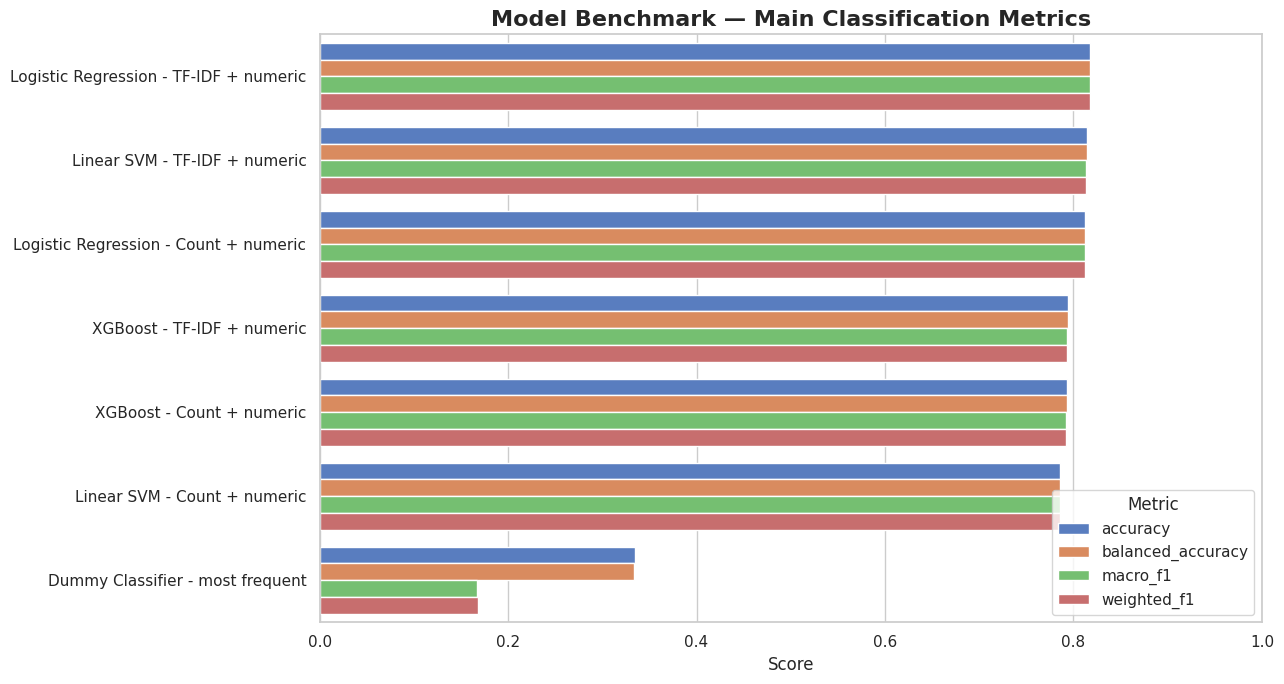

In [27]:

metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
plot_df = results_df.melt(
    id_vars=["model_name", "representation"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 7))
sns.barplot(data=plot_df, y="model_name", x="score", hue="metric")
plt.title("Model Benchmark — Main Classification Metrics", fontsize=16, fontweight="bold")
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0, 1)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()


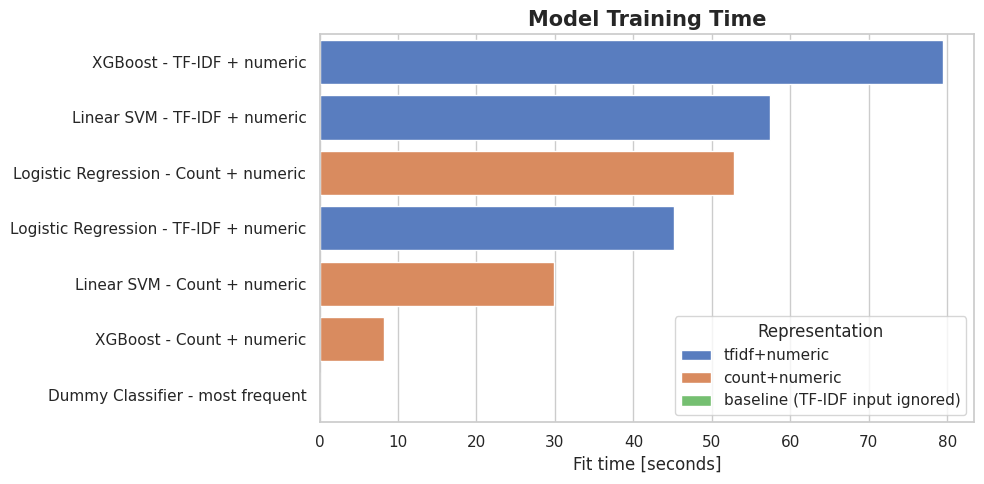

In [28]:

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df.sort_values("fit_time_sec", ascending=False),
    y="model_name",
    x="fit_time_sec",
    hue="representation",
    dodge=False,
)
plt.title("Model Training Time", fontsize=15, fontweight="bold")
plt.xlabel("Fit time [seconds]")
plt.ylabel("")
plt.legend(title="Representation")
plt.tight_layout()
plt.show()


### Best model details

In [29]:

best_model_name = results_df.loc[0, "model_name"]
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]
best_feature_names = model_feature_names[best_model_name]

print("Best model:", best_model_name)
print("Representation:", results_df.loc[0, "representation"])
print("Macro F1:", results_df.loc[0, "macro_f1"])
print("Accuracy:", results_df.loc[0, "accuracy"])

report = classification_report(y_test, best_pred, target_names=label_classes, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
display(report_df)


Best model: Logistic Regression - TF-IDF + numeric
Representation: tfidf+numeric
Macro F1: 0.8178380472095453
Accuracy: 0.8177834159843156


,precision,recall,f1-score,support
High,0.899326,0.877855,0.888461,2890.000000
Low,0.815075,0.837810,0.826286,2904.000000
Medium,0.740314,0.737226,0.738767,2877.000000
accuracy,0.817783,0.817783,0.817783,0.817783
macro avg,0.818239,0.817630,0.817838,8671.000000
weighted avg,0.818350,0.817783,0.817970,8671.000000


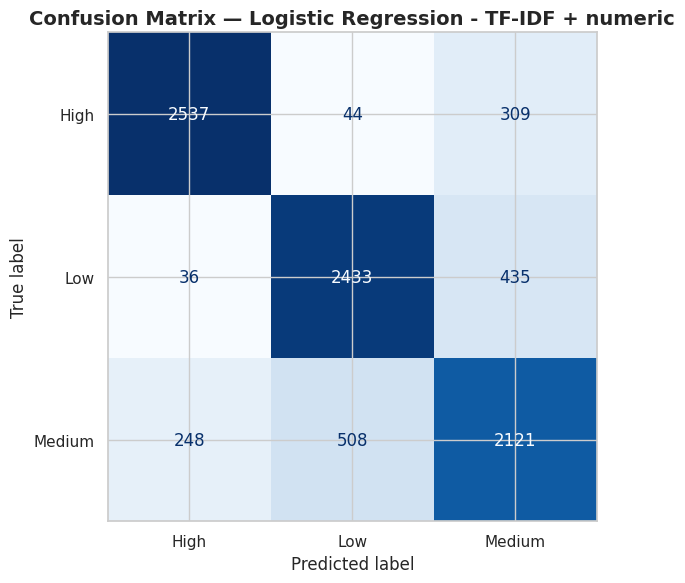

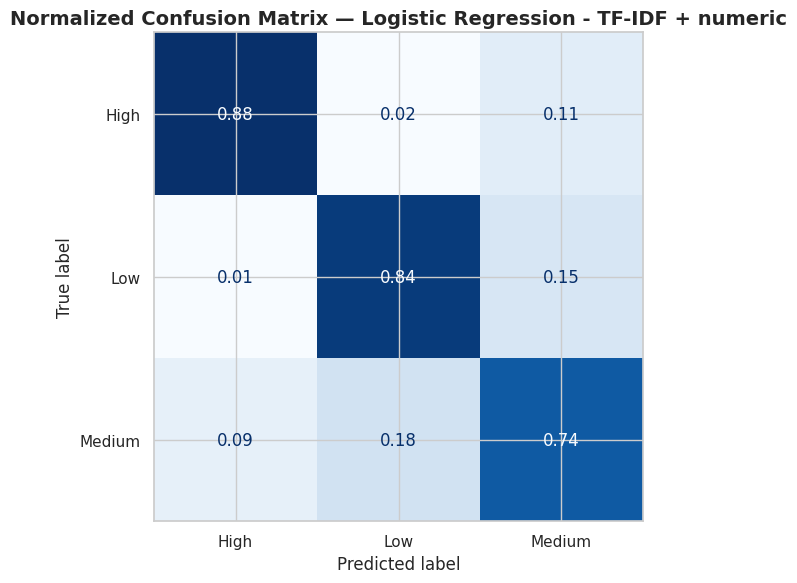

In [30]:

cm = confusion_matrix(y_test, best_pred, labels=np.arange(len(label_classes)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_classes)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_test, best_pred, labels=np.arange(len(label_classes)), normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_classes)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title(f"Normalized Confusion Matrix — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Confusion matrices for top models

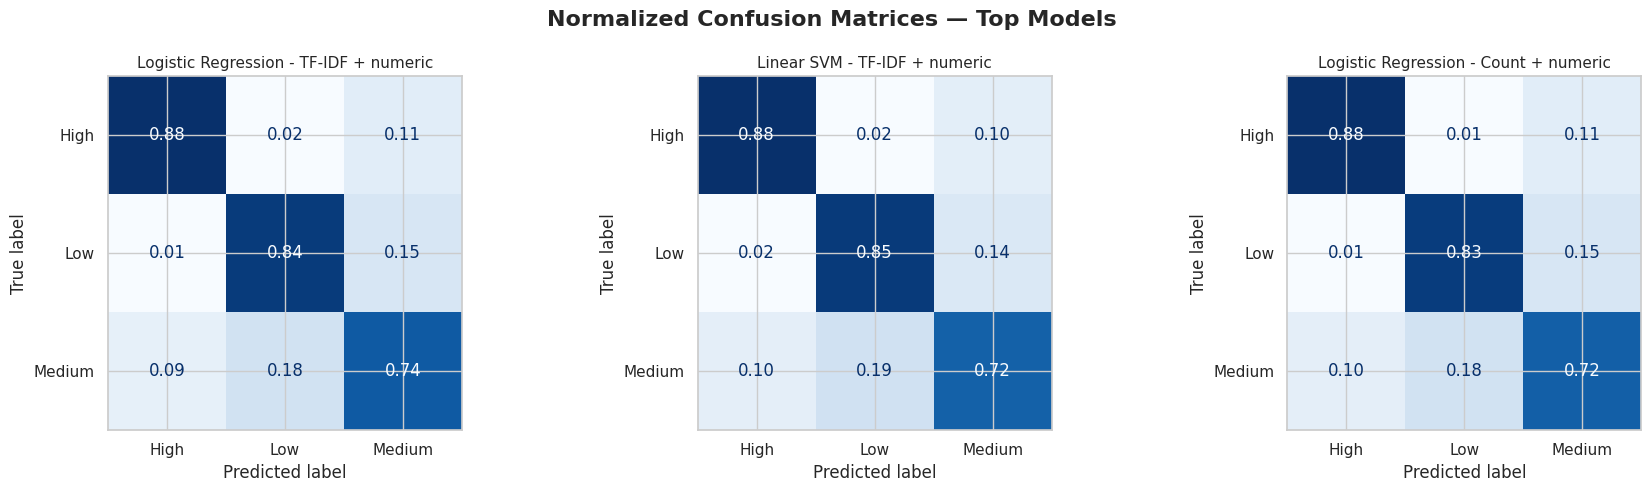

In [31]:

top_n = min(3, len(results_df))
top_model_names = results_df.head(top_n)["model_name"].tolist()

fig, axes = plt.subplots(1, top_n, figsize=(6 * top_n, 5))
if top_n == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_model_names):
    y_pred = predictions[model_name]
    cm_model = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_classes)), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_model, display_labels=label_classes)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(model_name, fontsize=11)

plt.suptitle("Normalized Confusion Matrices — Top Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### Linear model coefficient interpretation

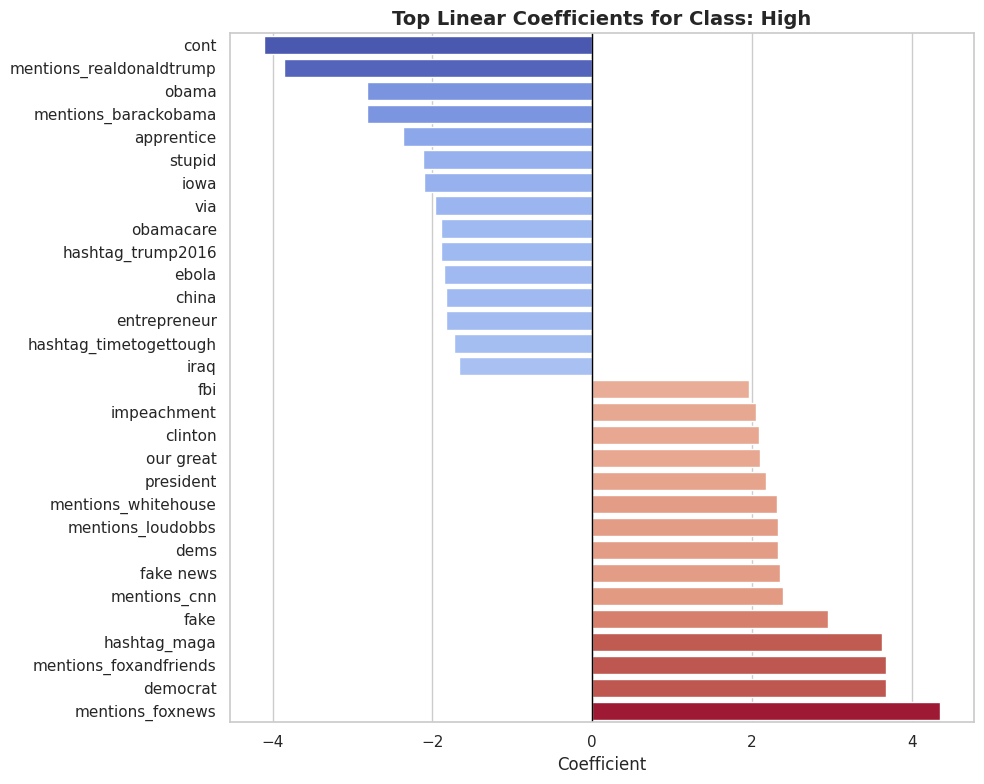

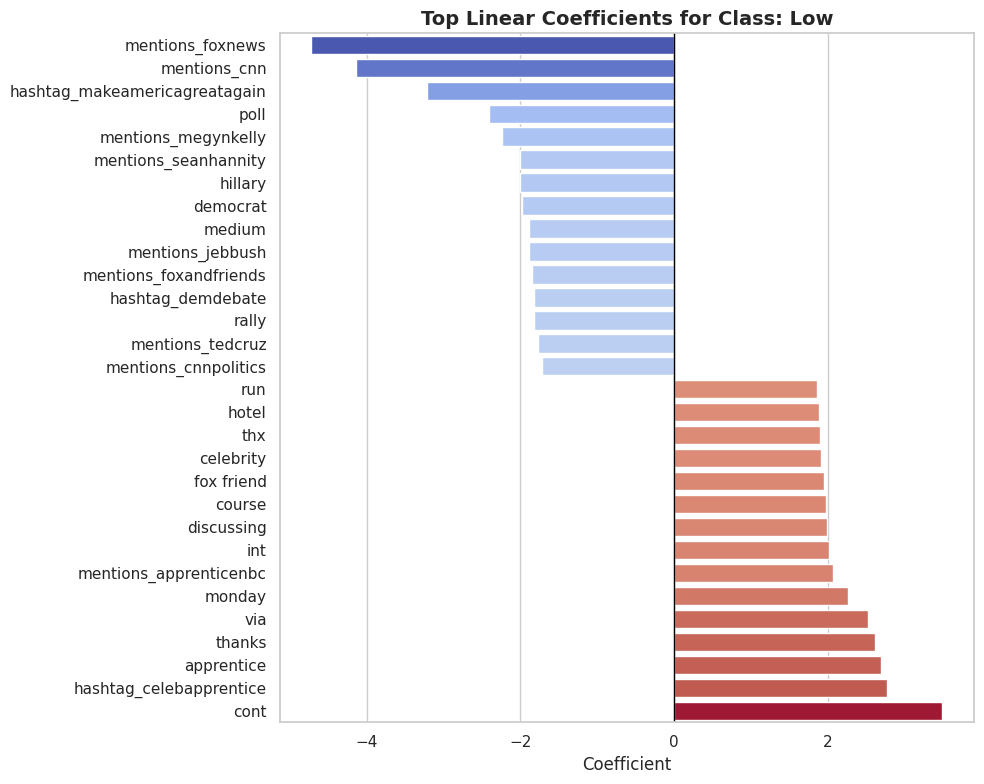

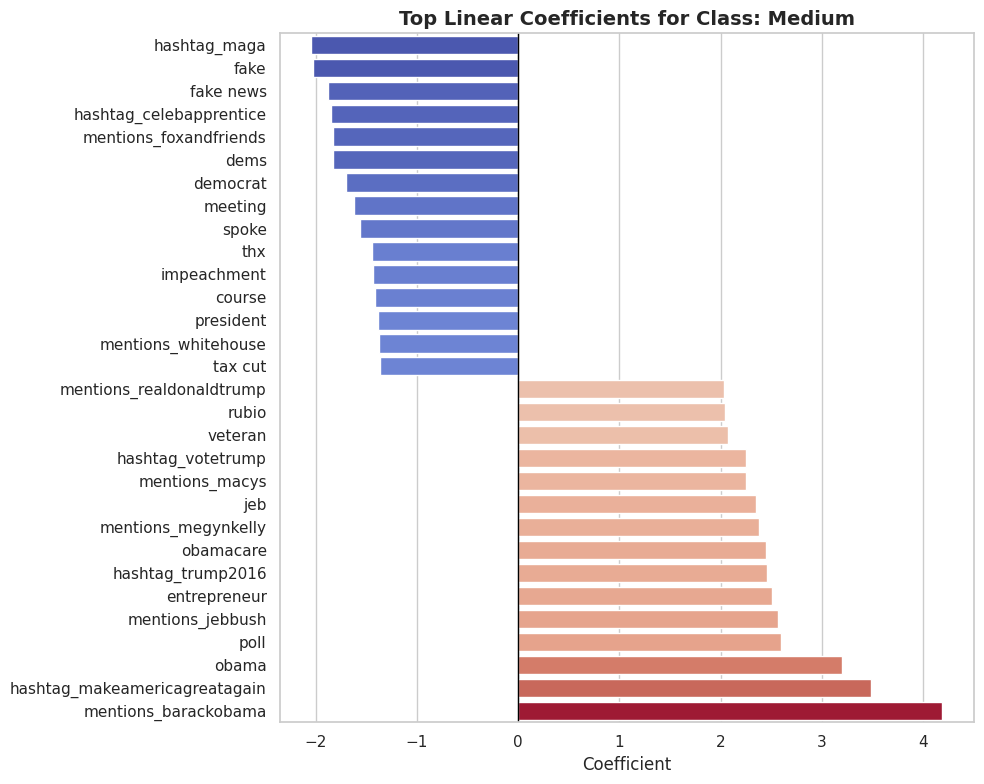

In [32]:

def plot_top_linear_features(model, feature_names, class_names, top_n=15):
    if not hasattr(model, "coef_"):
        print(f"Model {type(model).__name__} has no coef_ attribute. Skipping coefficient plots.")
        return

    coef = model.coef_
    if coef.ndim == 1:
        coef = coef.reshape(1, -1)

    n_classes_to_plot = min(len(class_names), coef.shape[0])

    for class_idx in range(n_classes_to_plot):
        class_name = class_names[class_idx]
        class_coef = coef[class_idx]
        top_pos_idx = np.argsort(class_coef)[-top_n:]
        top_neg_idx = np.argsort(class_coef)[:top_n]
        selected_idx = np.concatenate([top_neg_idx, top_pos_idx])

        coef_df = pd.DataFrame({
            "feature": [feature_names[i] for i in selected_idx],
            "coefficient": class_coef[selected_idx],
        }).sort_values("coefficient")

        plt.figure(figsize=(10, 8))
        sns.barplot(data=coef_df, x="coefficient", y="feature", hue="coefficient", legend=False, palette="coolwarm")
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Top Linear Coefficients for Class: {class_name}", fontsize=14, fontweight="bold")
        plt.xlabel("Coefficient")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

plot_top_linear_features(best_model, best_feature_names, label_classes, top_n=15)


### Error analysis

In [33]:

test_df = df.iloc[test_idx].copy()
test_df["actual_label"] = [label_classes[i] for i in y_test]
test_df["predicted_label"] = [label_classes[i] for i in best_pred]
test_df["is_correct"] = test_df["actual_label"] == test_df["predicted_label"]

error_cols = ["content", "retweets", "engagement_level", "actual_label", "predicted_label", "is_correct"]
if "prediction_score_max" in test_df.columns:
    error_cols.append("prediction_score_max")

mistakes = test_df.loc[~test_df["is_correct"], error_cols].copy()
print(f"Mistakes: {len(mistakes)} / {len(test_df)}")

with pd.option_context("display.max_colwidth", 180, "display.max_columns", None):
    examples = mistakes.sample(n=min(20, len(mistakes)), random_state=RANDOM_STATE)
    display(examples)


Mistakes: 1580 / 8671


,content,retweets,engagement_level,actual_label,predicted_label,is_correct
30539,"Paul Ryan, a man who doesn't know how to win (including failed run four years ago), must start focusing on the budget, military, vets etc.",9331,High,High,Medium,False
24773,LIVE on # Periscope: Watch major press conference live from @ TrumpTowerNY now! # MakeAmericaGreatAgain https://www.pscp.tv/w/aLiDwjEyMzE3NDF8MWxQSnFyb1JaUGV4YvTDyhu_D_t2nnlOmH...,792,Medium,Medium,High,False
3341,I really like Chelsea Clinton--an amazing young woman. She got the best of both parents. ( @ IvankaTrump agrees),7167,High,High,Medium,False
30110,""" @ Ler: Message for undecided voters: Please wake up and vote DonaldTrump now! Trump/Pence very important save our America before too late!""",5608,High,High,Medium,False
42436,They are one of the worst in the “news” business. Total slime balls!https://twitter.com/PressSec/status/1254460454971342854 …,13980,High,High,Medium,False
10381,""" @ desktodesk7: @ realDonaldTrump I'm hoping the history books read ""Donald Trump led America out of it's darkest times"". Wow, very nice!",266,Medium,Medium,Low,False
11590,I have just lost my beautiful & elegant long time exec. assistant Norma Foerderer. She passed away yesterday – a truly magnificent woman.,44,Low,Low,Medium,False
21892,""" @ foxandfriends: . @ realDonaldTrump on President Obama's statements in Panama: ""Our country is going to Hell...under his leadership.""""",22,Low,Low,Medium,False
27391,""". @ TheBrodyFile Exclusive: @ realDonaldTrump Says He Will Protect Evangelicals Better Than @ tedcruz http://www1.cbn.com/thebrodyfile/a … # CBNNews #2016""",825,Medium,Medium,Low,False
2808,BIG - 10K greeted @ MittRomney & @ PaulRyanVP in Wisconsin homecoming last night http://bit.ly/MV6qax @ MittRomnney made a great move!,41,Low,Low,Medium,False


### Save best model and benchmark artifacts

In [34]:

model_bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_names": best_feature_names,
    "label_classes": label_classes,
    "train_idx": train_idx,
    "test_idx": test_idx,
    "results": results_df,
    "methodological_note": (
        "Features were loaded from notebook 03, where vectorization/scaling/topic modeling "
        "were fitted on the full dataset for project simplicity. For strict evaluation, "
        "these steps should be placed inside a training-only sklearn Pipeline."
    ),
}

joblib.dump(model_bundle, MODELS_DIR / "best_engagement_model.joblib")

predictions_df = pd.DataFrame({
    "row_index": test_idx,
    "y_true": y_test,
    "y_pred": best_pred,
    "true_label": [label_classes[i] for i in y_test],
    "predicted_label": [label_classes[i] for i in best_pred],
})

print("Saved:")
print("-", MODELS_DIR / "best_engagement_model.joblib")


Saved:
- /home/patryk/Programming/MIO/social-media-engagement-prediction/models/best_engagement_model.joblib
